In [1]:
import glob
import os
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

In [2]:
ERA5_DIR = "../.data/ERA5/"
GRID_PATH = "../.data/GRIDMET/gridmet_4km_jja_ne/tmmx_JJA_NE_2000_2025.nc"

os.makedirs(ERA5_DIR, exist_ok=True)

In [3]:
def preprocess_era5_variable(
    file_pattern,
    var_name_in_file,
    var_name_out,
    save_path,
    grid_path=GRID_PATH,
):
    # ---------------------------
    # 1. find files
    # ---------------------------
    files = sorted(glob.glob(os.path.join(ERA5_DIR, file_pattern)))
    print(f"Found {len(files)} files for pattern: {file_pattern}")
    print(files[:3], "...", files[-3:] if len(files) >= 3 else files)

    if len(files) == 0:
        raise FileNotFoundError(f"No files found for pattern: {file_pattern}")

    # ---------------------------
    # 2. read and clean
    # ---------------------------
    datasets = []

    for f in files:
        ds = xr.open_dataset(f)

        # drop scalar coord if present
        if "number" in ds.coords:
            ds = ds.drop_vars("number")

        rename_dict = {}

        if "valid_time" in ds.coords:
            rename_dict["valid_time"] = "day"
        if "latitude" in ds.coords:
            rename_dict["latitude"] = "lat"
        if "longitude" in ds.coords:
            rename_dict["longitude"] = "lon"
        if var_name_in_file in ds.data_vars:
            rename_dict[var_name_in_file] = var_name_out

        ds = ds.rename(rename_dict)

        datasets.append(ds)

    # ---------------------------
    # 3. concatenate
    # ---------------------------
    ds_era5 = xr.concat(datasets, dim="day").sortby("day")

    # ---------------------------
    # 4. subset to GRIDMET extent
    # ---------------------------
    ds_grid = xr.open_dataset(grid_path)

    lat_min = float(ds_grid.lat.min())
    lat_max = float(ds_grid.lat.max())
    lon_min = float(ds_grid.lon.min())
    lon_max = float(ds_grid.lon.max())

    print("GRIDMET extent:")
    print(lat_min, lat_max, lon_min, lon_max)

    # ERA5 lat usually descending
    ds_era5_sub = ds_era5.sel(
        lat=slice(lat_max, lat_min),
        lon=slice(lon_min, lon_max)
    )

    # ---------------------------
    # 5. apply GRIDMET land mask on ERA5 grid
    # ---------------------------
    land_mask_gridmet = ds_grid["air_temperature"].notnull().any(dim="day")
    land_mask_gridmet_num = land_mask_gridmet.astype(int)

    land_mask_era5 = land_mask_gridmet_num.interp(
        lat=ds_era5_sub.lat,
        lon=ds_era5_sub.lon,
        method="nearest"
    )

    land_mask_era5 = land_mask_era5.fillna(0).astype(bool)

    ds_era5_sub_masked = ds_era5_sub.where(land_mask_era5)

    # ---------------------------
    # 6. save
    # ---------------------------
    ds_era5_sub_masked.to_netcdf(save_path)
    print(f"Saved to: {save_path}")

    return ds_era5_sub_masked

In [4]:
ds_d2m = preprocess_era5_variable(
    file_pattern="era5_d2m_dailymean_*.nc",
    var_name_in_file="d2m",
    var_name_out="d2m",
    save_path="../.data/ERA5/era5_d2m_dailymean_JJA_NE_2000_2025_masked.nc",
)

Found 78 files for pattern: era5_d2m_dailymean_*.nc
['../.data/ERA5/era5_d2m_dailymean_2000_06_jun_utc-04_47N-37N_80W-60W.nc', '../.data/ERA5/era5_d2m_dailymean_2000_07_jul_utc-04_47N-37N_80W-60W.nc', '../.data/ERA5/era5_d2m_dailymean_2000_08_aug_utc-04_47N-37N_80W-60W.nc'] ... ['../.data/ERA5/era5_d2m_dailymean_2025_06_jun_utc-04_47N-37N_80W-60W.nc', '../.data/ERA5/era5_d2m_dailymean_2025_07_jul_utc-04_47N-37N_80W-60W.nc', '../.data/ERA5/era5_d2m_dailymean_2025_08_aug_utc-04_47N-37N_80W-60W.nc']
GRIDMET extent:
37.025000000000006 46.983333333333334 -79.97499996666667 -67.05833330000002
Saved to: ../.data/ERA5/era5_d2m_dailymean_JJA_NE_2000_2025_masked.nc


In [5]:
ds_d2m

<xarray.Dataset> Size: 19MB
Dimensions:  (day: 2392, lat: 39, lon: 51)
Coordinates:
  * day      (day) datetime64[ns] 19kB 2000-06-01 2000-06-02 ... 2025-08-31
  * lat      (lat) float64 312B 46.75 46.5 46.25 46.0 ... 38.0 37.75 37.5 37.25
  * lon      (lon) float64 408B -79.75 -79.5 -79.25 ... -67.75 -67.5 -67.25
Data variables:
    d2m      (day, lat, lon) float32 19MB nan nan nan nan ... nan nan nan nan
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-04-14T19:23 GRIB to CDM+CF via cfgrib-0.9.1...

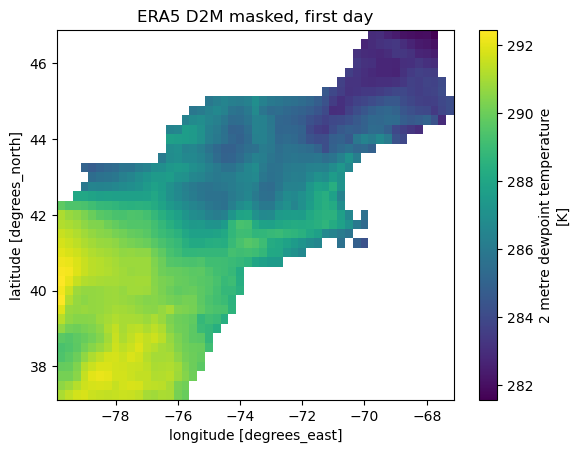

In [6]:
ds_d2m["d2m"].isel(day=0).plot()
plt.title("ERA5 D2M masked, first day")
plt.show()

In [7]:
ds_ssrd = preprocess_era5_variable(
    file_pattern="era5_ssrd_dailymean_*.nc",
    var_name_in_file="ssrd",
    var_name_out="ssrd",
    save_path="../.data/ERA5/era5_ssrd_dailymean_JJA_NE_2000_2025_masked.nc",
)

Found 78 files for pattern: era5_ssrd_dailymean_*.nc
['../.data/ERA5/era5_ssrd_dailymean_2000_06_jun_utc-04_47N-37N_80W-60W.nc', '../.data/ERA5/era5_ssrd_dailymean_2000_07_jul_utc-04_47N-37N_80W-60W.nc', '../.data/ERA5/era5_ssrd_dailymean_2000_08_aug_utc-04_47N-37N_80W-60W.nc'] ... ['../.data/ERA5/era5_ssrd_dailymean_2025_06_jun_utc-04_47N-37N_80W-60W.nc', '../.data/ERA5/era5_ssrd_dailymean_2025_07_jul_utc-04_47N-37N_80W-60W.nc', '../.data/ERA5/era5_ssrd_dailymean_2025_08_aug_utc-04_47N-37N_80W-60W.nc']
GRIDMET extent:
37.025000000000006 46.983333333333334 -79.97499996666667 -67.05833330000002
Saved to: ../.data/ERA5/era5_ssrd_dailymean_JJA_NE_2000_2025_masked.nc


In [8]:
ds_ssrd

<xarray.Dataset> Size: 19MB
Dimensions:  (day: 2392, lat: 39, lon: 51)
Coordinates:
  * day      (day) datetime64[ns] 19kB 2000-06-01 2000-06-02 ... 2025-08-31
  * lat      (lat) float64 312B 46.75 46.5 46.25 46.0 ... 38.0 37.75 37.5 37.25
  * lon      (lon) float64 408B -79.75 -79.5 -79.25 ... -67.75 -67.5 -67.25
Data variables:
    ssrd     (day, lat, lon) float32 19MB nan nan nan nan ... nan nan nan nan
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-04-14T21:37 GRIB to CDM+CF via cfgrib-0.9.1...

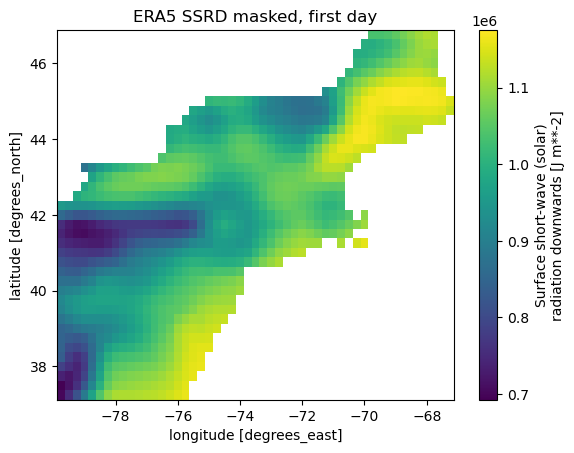

In [9]:
ds_ssrd["ssrd"].isel(day=0).plot()
plt.title("ERA5 SSRD masked, first day")
plt.show()

In [10]:
print(ds_ssrd.day.min().values, ds_ssrd.day.max().values, ds_ssrd.sizes["day"])
print(ds_d2m.day.min().values, ds_d2m.day.max().values, ds_d2m.sizes["day"])

2000-06-01T00:00:00.000000000 2025-08-31T00:00:00.000000000 2392
2000-06-01T00:00:00.000000000 2025-08-31T00:00:00.000000000 2392


In [11]:
print(np.allclose(ds_ssrd.lat.values, ds_d2m.lat.values))
print(np.allclose(ds_ssrd.lon.values, ds_d2m.lon.values))

True
True
